# 06 - Team & League Composition

This notebook takes a squad-building lens on the FC26 player pool:

1. **Best XI per major league** under a fixed 4-3-3 formation.
2. **League strength comparison** - not just the best players, but the full depth-of-quality distribution.
3. **Squad-building on a budget** - the cheapest way (by in-game `value_eur`) to field an XI that clears a given average-overall bar.
4. **Nation-level analysis** - raw talent-pool counts, average quality, and a "best XI regardless of position" ranking by nationality.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

df = pd.read_csv("../data/processed/players_fc26_clean.csv")
print(f"{len(df):,} total players, {df['league_name'].nunique()} leagues, "
      f"{df['club_name'].nunique()} clubs, {df['nationality_name'].nunique()} nationalities")

18,405 total players, 42 leagues, 662 clubs, 160 nationalities


## Setup: position groups and primary position

In [2]:
POSITION_GROUP = {
    "GK": "Goalkeeper",
    "CB": "Defender", "LCB": "Defender", "RCB": "Defender",
    "LB": "Defender", "RB": "Defender", "LWB": "Defender", "RWB": "Defender",
    "CDM": "Midfielder", "LDM": "Midfielder", "RDM": "Midfielder",
    "CM": "Midfielder", "LCM": "Midfielder", "RCM": "Midfielder",
    "CAM": "Midfielder", "LAM": "Midfielder", "RAM": "Midfielder",
    "LM": "Midfielder", "RM": "Midfielder",
    "LW": "Attacker", "RW": "Attacker",
    "CF": "Attacker", "LF": "Attacker", "RF": "Attacker",
    "ST": "Attacker", "LS": "Attacker", "RS": "Attacker",
}

def primary_position(pos_str):
    if pd.isna(pos_str):
        return np.nan
    return str(pos_str).split(",")[0].strip()

df["primary_position"] = df["player_positions"].apply(primary_position)
df["position_group"] = df["primary_position"].map(POSITION_GROUP)
df["position_group"].value_counts(dropna=False)

position_group
Midfielder    6864
Defender      6116
Attacker      3363
Goalkeeper    2062
Name: count, dtype: int64

## 1. Best XI per major league (4-3-3)

We define a fixed 4-3-3 with 11 named slots, each eligible for a small set of primary positions, and greedily fill each slot with the highest-`overall` remaining player at that league who qualifies - so no player is used twice. This picks the best *theoretical* XI available in a league, not an actual matchday XI.

In [3]:
FORMATION_433 = [
    ("GK",  ["GK"]),
    ("RB",  ["RB", "RWB"]),
    ("CB1", ["CB"]),
    ("CB2", ["CB"]),
    ("LB",  ["LB", "LWB"]),
    ("CDM", ["CDM", "LDM", "RDM"]),
    ("CM1", ["CM", "LCM", "RCM"]),
    ("CM2", ["CM", "LCM", "RCM", "CAM"]),
    ("RW",  ["RW", "RM"]),
    ("ST",  ["ST", "CF", "LS", "RS"]),
    ("LW",  ["LW", "LM"]),
]

def best_xi(pool, formation=FORMATION_433):
    """Greedily fill each formation slot with the best remaining eligible player."""
    used_ids = set()
    rows = []
    for slot, eligible in formation:
        candidates = pool[
            pool["primary_position"].isin(eligible) & ~pool["player_id"].isin(used_ids)
        ].sort_values("overall", ascending=False)
        if candidates.empty:
            rows.append({"slot": slot, "short_name": None, "overall": np.nan})
            continue
        pick = candidates.iloc[0]
        used_ids.add(pick["player_id"])
        rows.append({
            "slot": slot, "short_name": pick["short_name"], "primary_position": pick["primary_position"],
            "overall": pick["overall"], "age": pick["age"], "club_name": pick["club_name"],
        })
    return pd.DataFrame(rows)


MAJOR_LEAGUES = [
    "Premier League", "La Liga", "Serie A", "Bundesliga", "Ligue 1",
    "Eredivisie", "Primeira Liga", "Süper Lig", "Major League Soccer",
]

xi_summaries = {}
for league in MAJOR_LEAGUES:
    pool = df[df["league_name"] == league]
    xi = best_xi(pool)
    xi_summaries[league] = xi

# Show the Premier League Best XI as a worked example
xi_summaries["Premier League"]

,slot,short_name,primary_position,overall,age,club_name
0,GK,Alisson,GK,89,32,Liverpool
1,RB,J. Frimpong,RB,83,24,Liverpool
2,CB1,V. van Dijk,CB,90,33,Liverpool
3,CB2,Gabriel,CB,88,27,Arsenal
4,LB,Marc Cucurella,LB,84,26,Chelsea
5,CDM,Rodri,CDM,90,29,Manchester City
6,CM1,A. Mac Allister,CM,87,26,Liverpool
7,CM2,F. Wirtz,CAM,89,22,Liverpool
8,RW,M. Salah,RM,91,33,Liverpool
9,ST,E. Haaland,ST,90,24,Manchester City


In [4]:
league_xi_strength = pd.DataFrame({
    league: {
        "avg_overall": xi["overall"].mean(),
        "min_overall": xi["overall"].min(),
        "avg_age": xi["age"].mean(),
    }
    for league, xi in xi_summaries.items()
}).T.sort_values("avg_overall", ascending=False)

league_xi_strength.round(1)

,avg_overall,min_overall,avg_age
Premier League,87.7,83.0,27.5
La Liga,87.4,83.0,25.5
Ligue 1,86.3,82.0,24.6
Bundesliga,85.9,82.0,26.6
Serie A,85.8,84.0,28.6
Süper Lig,81.6,76.0,29.4
Primeira Liga,81.1,78.0,27.5
Major League Soccer,79.3,73.0,34.5
Eredivisie,78.7,76.0,27.1


C:\Users\thoma\AppData\Local\Temp\ipykernel_18400\1014477408.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=league_xi_strength["avg_overall"], y=order, ax=ax, palette="deep")


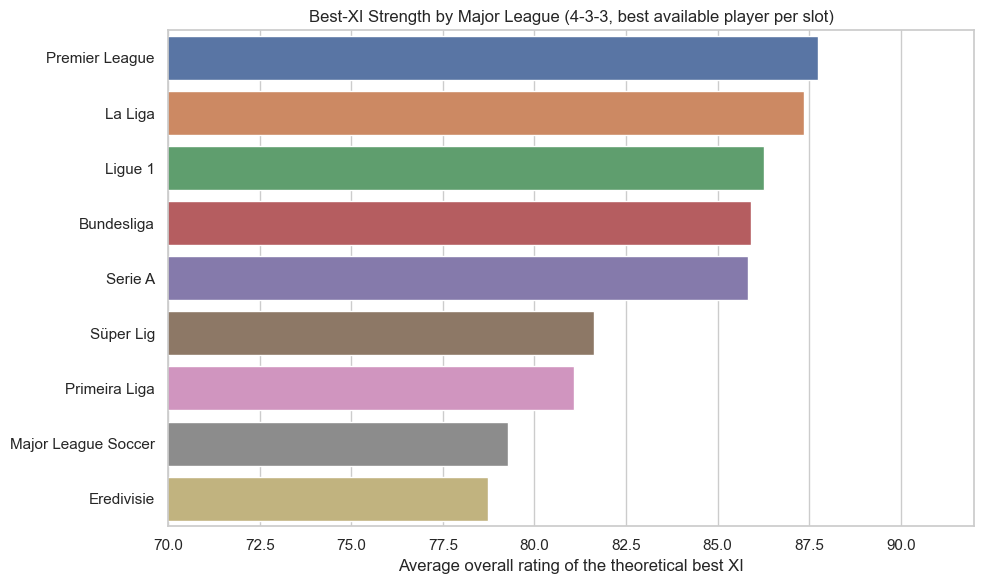

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
order = league_xi_strength.index
sns.barplot(x=league_xi_strength["avg_overall"], y=order, ax=ax, palette="deep")
ax.set_xlabel("Average overall rating of the theoretical best XI")
ax.set_ylabel("")
ax.set_title("Best-XI Strength by Major League (4-3-3, best available player per slot)")
ax.set_xlim(70, 92)
plt.tight_layout()
plt.show()

**Takeaway:** the Premier League and La Liga field the strongest theoretical best XIs by a clear margin, consistent with them hosting the largest concentration of elite individual talent - but this metric only reflects the ceiling, not the depth, of a league.

## 2. League strength: depth, not just the ceiling

A best-XI comparison only looks at the top 11 players. To compare league *depth*, we look at the full distribution of `overall` across every player registered in each league.

C:\Users\thoma\AppData\Local\Temp\ipykernel_18400\2884179132.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=major, x="overall", y="league_name", order=order, ax=ax,


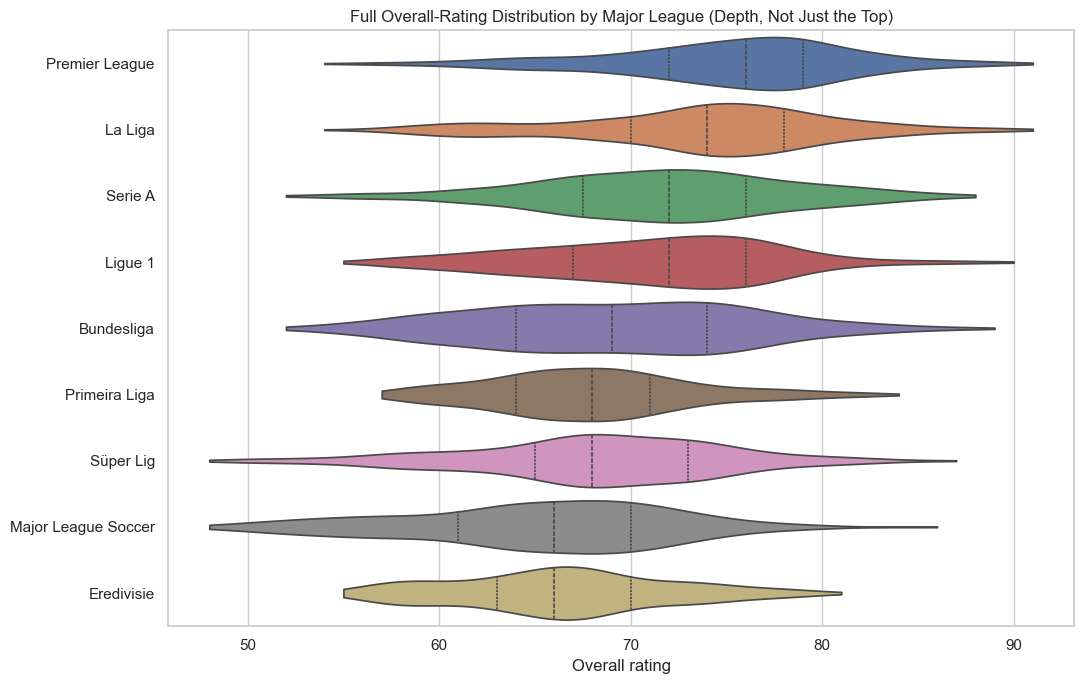

In [6]:
major = df[df["league_name"].isin(MAJOR_LEAGUES)].copy()

fig, ax = plt.subplots(figsize=(11, 7))
order = major.groupby("league_name")["overall"].median().sort_values(ascending=False).index
sns.violinplot(data=major, x="overall", y="league_name", order=order, ax=ax,
               palette="deep", cut=0, inner="quartile")
ax.set_xlabel("Overall rating")
ax.set_ylabel("")
ax.set_title("Full Overall-Rating Distribution by Major League (Depth, Not Just the Top)")
plt.tight_layout()
plt.show()

In [7]:
depth = major.groupby("league_name")["overall"].agg(
    n_players="count", median="median", p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75)
)
depth["pct_80_plus"] = major.groupby("league_name")["overall"].apply(lambda s: (s >= 80).mean() * 100)
depth["pct_75_plus"] = major.groupby("league_name")["overall"].apply(lambda s: (s >= 75).mean() * 100)
depth = depth.sort_values("median", ascending=False).round(1)
depth

,n_players,median,p25,p75,pct_80_plus,pct_75_plus
league_name,,,,,,
Premier League,609,76.0,72.0,79.0,23.0,60.6
La Liga,554,74.0,70.0,78.0,15.9,49.6
Serie A,687,72.0,67.5,76.0,11.8,32.6
Ligue 1,488,72.0,67.0,76.0,6.6,32.2
Bundesliga,866,69.0,64.0,74.0,6.9,24.0
Primeira Liga,522,68.0,64.0,71.0,2.9,11.3
Süper Lig,469,68.0,65.0,73.0,4.5,14.5
Major League Soccer,803,66.0,61.0,70.0,0.7,6.7
Eredivisie,526,66.0,63.0,70.0,0.6,8.6


**Takeaway:** the Premier League and Bundesliga stand out for *depth* - a high share of their full squads (not just the best XI) clear the 75+ and 80+ overall bars - whereas MLS has a much wider spread (visible as a fatter, lower-median violin), reflecting a mix of designated-player-level talent alongside a long tail of much lower-rated squad players. This is a meaningfully different picture than the best-XI ranking above: a league can have an elite ceiling (top XI) without matching depth across the full player pool, or vice versa.

## 3. Squad-building on a value budget

Given the 4-3-3 formation above, what is the *cheapest* (by in-game `value_eur`) way to field an XI where every single starter clears a target overall rating? We sweep several target thresholds and, for each, greedily pick the cheapest qualifying player per slot (across the entire dataset, not one league) to trace out a cost-vs-quality curve.

In [8]:
def cheapest_qualifying_xi(pool, min_overall, formation=FORMATION_433):
    used_ids = set()
    rows = []
    for slot, eligible in formation:
        candidates = pool[
            pool["primary_position"].isin(eligible)
            & (pool["overall"] >= min_overall)
            & ~pool["player_id"].isin(used_ids)
        ].sort_values("value_eur", ascending=True)
        if candidates.empty:
            rows.append({"slot": slot, "short_name": None, "overall": np.nan, "value_eur": np.nan})
            continue
        pick = candidates.iloc[0]
        used_ids.add(pick["player_id"])
        rows.append({
            "slot": slot, "short_name": pick["short_name"], "primary_position": pick["primary_position"],
            "overall": pick["overall"], "value_eur": pick["value_eur"], "club_name": pick["club_name"],
        })
    return pd.DataFrame(rows)


thresholds = [70, 75, 78, 80, 82, 84, 86]
cost_curve = []
for thr in thresholds:
    xi = cheapest_qualifying_xi(df, thr)
    cost_curve.append({
        "min_overall": thr,
        "total_value_eur": xi["value_eur"].sum(),
        "avg_overall": xi["overall"].mean(),
    })
cost_curve = pd.DataFrame(cost_curve)
cost_curve["total_value_m"] = (cost_curve["total_value_eur"] / 1e6).round(1)
cost_curve[["min_overall", "avg_overall", "total_value_m"]]

,min_overall,avg_overall,total_value_m
0,70,73.545455,0.0
1,75,77.272727,1.2
2,78,78.636364,18.1
3,80,81.000000,84.0
4,82,83.000000,134.0
5,84,84.363636,242.2
6,86,86.454545,554.5


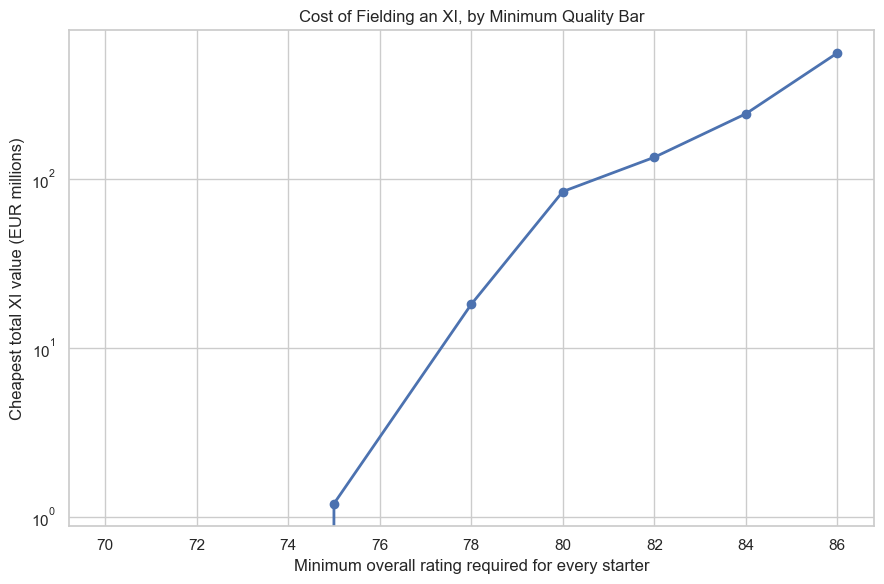

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(cost_curve["min_overall"], cost_curve["total_value_m"], marker="o", linewidth=2)
ax.set_xlabel("Minimum overall rating required for every starter")
ax.set_ylabel("Cheapest total XI value (EUR millions)")
ax.set_title("Cost of Fielding an XI, by Minimum Quality Bar")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

**Takeaway:** the cost curve is roughly flat (and cheap - low tens of millions) up to a ~78-80 minimum-overall bar, then rises steeply and non-linearly beyond 82+, because the pool of eligible, still-affordable players at each slot collapses fast once every starter must be elite - a small number of undervalued high-overall players (young academy graduates, smaller-league standouts) keep the budget low until the bar gets high enough to force a shopping list of only genuinely elite, expensive players.

In [10]:
# Worked example: the cheapest XI that clears an 80+ overall bar for every starter
example_xi = cheapest_qualifying_xi(df, 80)
example_xi["value_eur"] = example_xi["value_eur"].map(lambda v: f"€{v:,.0f}" if pd.notna(v) else v)
example_xi

,slot,short_name,primary_position,overall,value_eur,club_name
0,GK,L. Hrádecký,GK,81,"€2,900,000",AS Monaco
1,RB,K. Trippier,RB,80,"€7,500,000",Newcastle United
2,CB1,N. Otamendi,CB,82,"€5,500,000",SL Benfica
3,CB2,C. Smalling,CB,80,"€5,500,000",Al Fayha
4,LB,R. Guerreiro,LB,80,"€15,500,000",FC Bayern München
5,CDM,Sergio Busquets,CDM,80,"€4,099,999",Inter Miami
6,CM1,Parejo,CM,82,"€9,500,000",Villarreal CF
7,CM2,T. Müller,CAM,80,"€8,500,000",Vancouver Whitecaps FC
8,RW,I. Perišić,RW,81,"€8,500,000",PSV
9,ST,Cristiano Ronaldo,ST,85,€0,Al Nassr


**Takeaway:** this XI is built purely from the cheapest 80+ overall player available at each slot in the entire game - it surfaces a real "Moneyball" starting point (mixing academy prospects and lower-profile-league standouts), similar in spirit to notebook 04's undervalued-player analysis but constrained to a complete, formation-legal XI rather than an unconstrained ranked list.

## 4. Nation-level analysis

How does talent concentrate by nationality - both in raw numbers and in average quality? We also build a "best XI regardless of position" per nation (just the top 11 players by overall) as a rough proxy for current national-team strength.

C:\Users\thoma\AppData\Local\Temp\ipykernel_18400\3996956026.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_nations_by_count.values, y=top_nations_by_count.index, ax=ax, palette="deep")


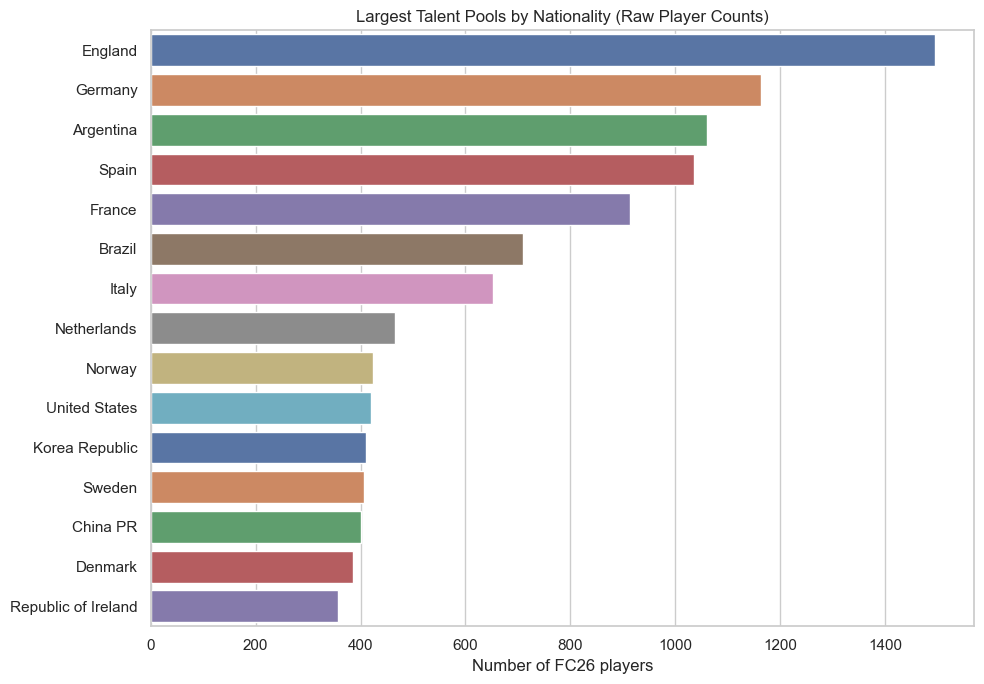

In [11]:
nat_counts = df["nationality_name"].value_counts()
top_nations_by_count = nat_counts.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_nations_by_count.values, y=top_nations_by_count.index, ax=ax, palette="deep")
ax.set_xlabel("Number of FC26 players")
ax.set_ylabel("")
ax.set_title("Largest Talent Pools by Nationality (Raw Player Counts)")
plt.tight_layout()
plt.show()

In [12]:
MIN_PLAYERS = 20
nat_quality = df.groupby("nationality_name")["overall"].agg(n="count", mean_overall="mean", median_overall="median")
nat_quality = nat_quality[nat_quality["n"] >= MIN_PLAYERS].sort_values("mean_overall", ascending=False)
print(f"Highest average overall by nation (min {MIN_PLAYERS} players):")
nat_quality.head(15).round(1)

Highest average overall by nation (min 20 players):


,n,mean_overall,median_overall
nationality_name,,,
Czechia,93,71.2,72.0
Algeria,60,70.6,71.0
Mexico,44,70.6,72.5
Brazil,709,70.6,71.0
Portugal,349,69.7,69.0
Ukraine,95,69.2,69.0
Spain,1036,69.2,69.0
Croatia,166,69.1,69.0
Slovakia,57,68.9,68.0


In [13]:
print(f"Lowest average overall by nation (min {MIN_PLAYERS} players):")
nat_quality.tail(10).round(1)

Lowest average overall by nation (min 20 players):


,n,mean_overall,median_overall
nationality_name,,,
Wales,144,63.2,63.0
Romania,294,63.1,63.0
Bolivia,77,62.2,63.0
New Zealand,55,62.0,62.0
Republic of Ireland,356,61.7,61.0
Australia,308,61.1,61.5
Korea Republic,411,60.4,61.0
Saudi Arabia,353,58.5,58.0
China PR,401,56.2,56.0


**Takeaway:** average overall (min. 20 players) is topped by a mix of traditional powers (Brazil, Portugal, Croatia) and nations with a smaller but concentrated top-flight presence (Czechia, Algeria, Mexico), while national talent pools with a large volume of domestic-league-only players (India, China PR, Saudi Arabia, Korea Republic) sit at the bottom - a reminder that this metric is pulled down by *any* nation whose pool is mostly lower-division or domestic-league players rather than a signal of weaker top-end technical talent per se.

In [14]:
def best_xi_any_position(pool, n=11):
    """Top-N players by overall, ignoring formation/position - a rough proxy for
    current national-team strength (no positional balance constraint)."""
    return pool.sort_values("overall", ascending=False).head(n)

nation_best11 = (
    df[df["nationality_name"].isin(nat_quality.index)]
    .groupby("nationality_name")
    .apply(lambda g: best_xi_any_position(g)["overall"].mean(), include_groups=False)
    .sort_values(ascending=False)
)
nation_best11.head(20).round(1).to_frame("best11_avg_overall")

,best11_avg_overall
nationality_name,
France,86.7
Spain,86.5
Brazil,86.4
England,86.1
Germany,85.7
Portugal,85.3
Italy,85.1
Argentina,85.0
Netherlands,84.7


C:\Users\thoma\AppData\Local\Temp\ipykernel_18400\344002597.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20.values, y=top20.index, ax=ax, palette="deep")


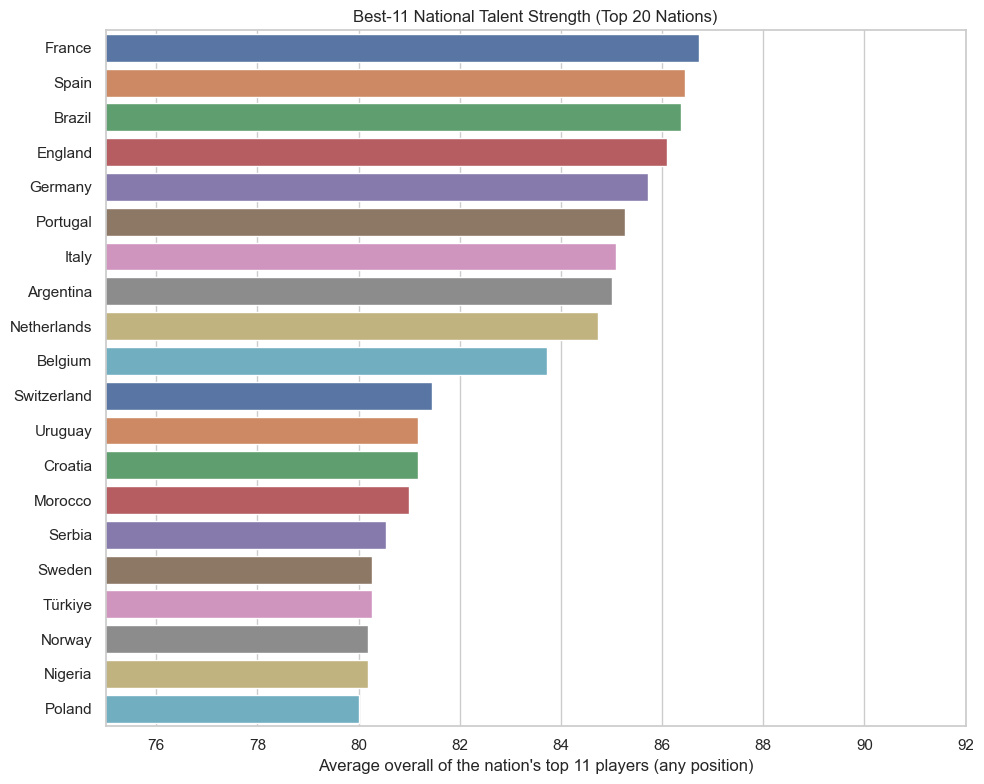

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
top20 = nation_best11.head(20)
sns.barplot(x=top20.values, y=top20.index, ax=ax, palette="deep")
ax.set_xlabel("Average overall of the nation's top 11 players (any position)")
ax.set_ylabel("")
ax.set_title("Best-11 National Talent Strength (Top 20 Nations)")
ax.set_xlim(75, 92)
plt.tight_layout()
plt.show()

**Takeaway:** the best-11 ranking reshuffles the raw-count leaderboard meaningfully - smaller nations with concentrated elite talent (e.g. Portugal, Belgium, Croatia, Uruguay) rank above larger player pools like England or Germany on peak quality alone, which matches the intuition that squad *depth* (raw counts) and squad *peak strength* (best-11 average) are genuinely different questions with different answers.

### A rough per-capita view

For a small set of major footballing nations where population is well known, we can sanity-check whether large talent pools are simply a function of population size. Population figures below are rounded, approximate (recent public estimates in millions) and included only for illustrative, order-of-magnitude comparison - not for precise ranking.

In [16]:
# Approximate population, in millions (rounded; for illustrative order-of-magnitude use only)
POPULATION_M = {
    "England": 57, "Germany": 84, "Argentina": 46, "Spain": 47, "France": 68,
    "Brazil": 215, "Italy": 59, "Netherlands": 18, "Norway": 5.5, "United States": 335,
    "Korea Republic": 52, "Sweden": 10.5, "Denmark": 5.9, "Republic of Ireland": 5.2,
    "Portugal": 10.3, "Poland": 37, "Belgium": 11.7, "Australia": 26,
    "Uruguay": 3.4, "Switzerland": 8.8, "Colombia": 52, "Chile": 19.5, "Croatia": 3.9,
    "Nigeria": 223, "Morocco": 37, "Senegal": 18, "Ghana": 33, "Japan": 124,
    "Mexico": 128, "Scotland": 5.5, "Wales": 3.2,
}

percapita = nat_counts[nat_counts.index.isin(POPULATION_M)].to_frame("n_players")
percapita["population_m"] = percapita.index.map(POPULATION_M)
percapita["players_per_10m_pop"] = (percapita["n_players"] / percapita["population_m"] * 10).round(2)
percapita = percapita[percapita["n_players"] >= MIN_PLAYERS].sort_values("players_per_10m_pop", ascending=False)
percapita.head(15)

,n_players,population_m,players_per_10m_pop
nationality_name,,,
Norway,424,5.5,770.91
Uruguay,248,3.4,729.41
Republic of Ireland,356,5.2,684.62
Denmark,385,5.9,652.54
Scotland,265,5.5,481.82
Wales,144,3.2,450.00
Croatia,166,3.9,425.64
Sweden,406,10.5,386.67
Portugal,349,10.3,338.83


**Takeaway:** on a per-capita basis, small nations with outsized football cultures - Uruguay, Croatia, Norway, Denmark, Belgium - produce far more professional-grade FC26 players relative to their population than population giants like the United States, Brazil, or Mexico, underscoring that footballing infrastructure and culture matter far more than raw population for producing professional talent.

## Summary

- A fixed 4-3-3 best-XI build shows the Premier League and La Liga hold the strongest *peak* talent among major leagues, but full-distribution depth analysis (violin plots, percentage of players clearing 75/80 overall) tells a different story - depth and ceiling don't always move together across leagues.
- Sweeping a minimum-overall bar across the whole player pool traces a cost curve that stays flat and cheap up to ~78-80 overall per starter, then rises sharply - useful intuition for how expensive "every starter must be elite" really is versus a merely good XI.
- Nation-level talent is best understood through at least three lenses that each answer a different question: raw counts (pool size), average quality with a minimum-sample filter (baseline quality), and best-11 average (peak strength) - and a rough per-capita cut shows footballing culture outweighs population size by a wide margin.